<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab1_perceptron_banknote_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
from google.colab import files
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))

Saving Perceptron_Banknote_Experiment.ipynb to Perceptron_Banknote_Experiment.ipynb
Uploaded files: ['Perceptron_Banknote_Experiment.ipynb']


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import Perceptron

sns.set_style("whitegrid")
np.random.seed(42)

In [63]:
columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=columns)

print("First 5 samples:")
display(df.head())

print("\nDataset dimensions (rows, columns):", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

print("\nClass distribution:")
print(df["Class"].value_counts())

First 5 samples:


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Dataset dimensions (rows, columns): (1372, 5)

Missing values per column:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive statistics:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000



Class distribution:
Class
0    762
1    610
Name: count, dtype: int64


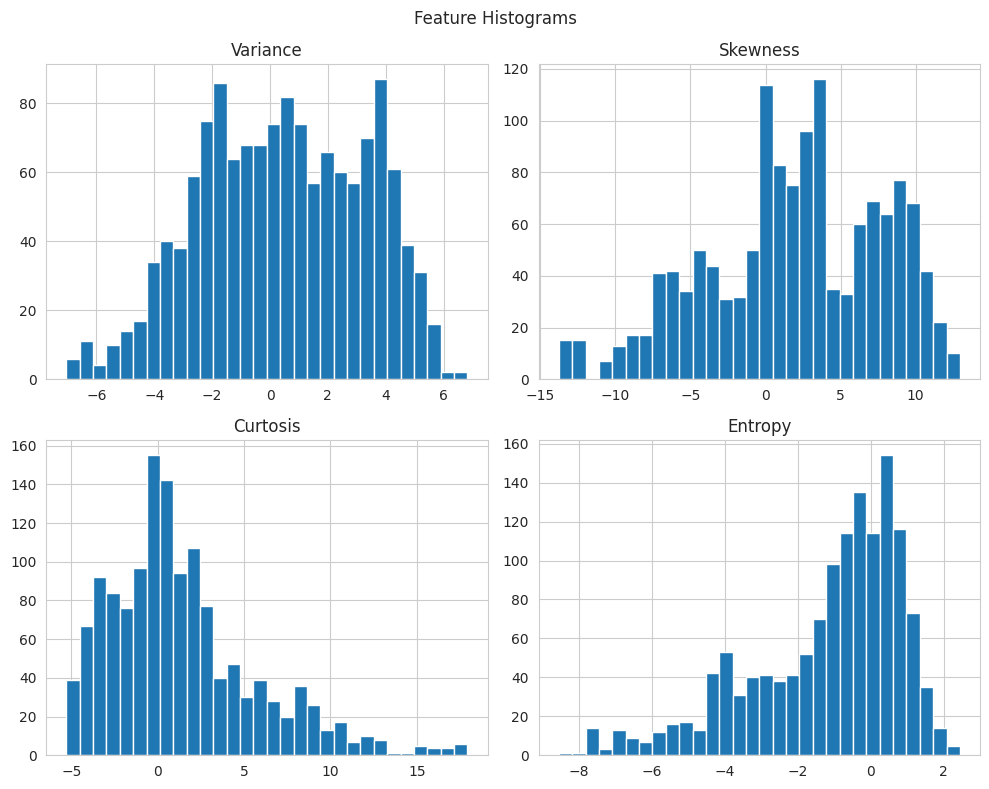

In [64]:
# Feature Histograms
df.hist(column=["Variance", "Skewness", "Curtosis", "Entropy"], bins=30, figsize=(10, 8))
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.show()

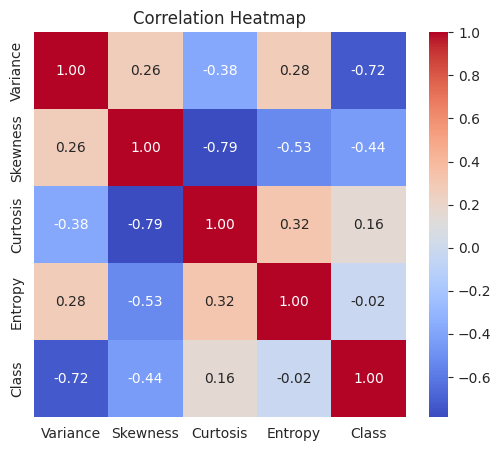

In [65]:
#  Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

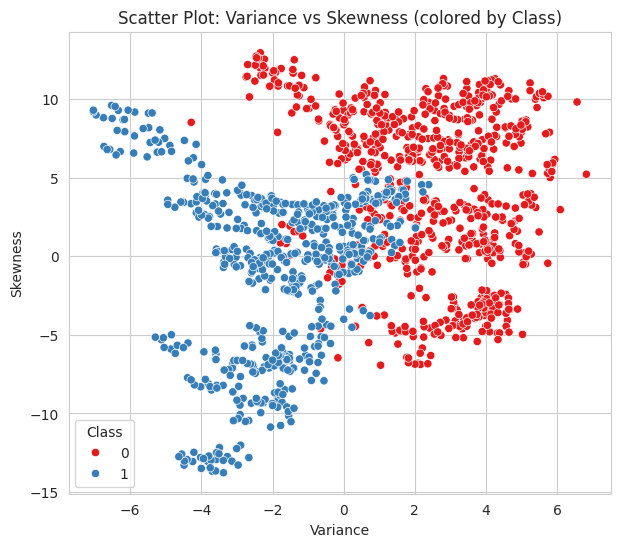

In [66]:
# Class Distribution using two features
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Variance", y="Skewness", hue="Class", palette="Set1")
plt.title("Scatter Plot: Variance vs Skewness (colored by Class)")
plt.show()

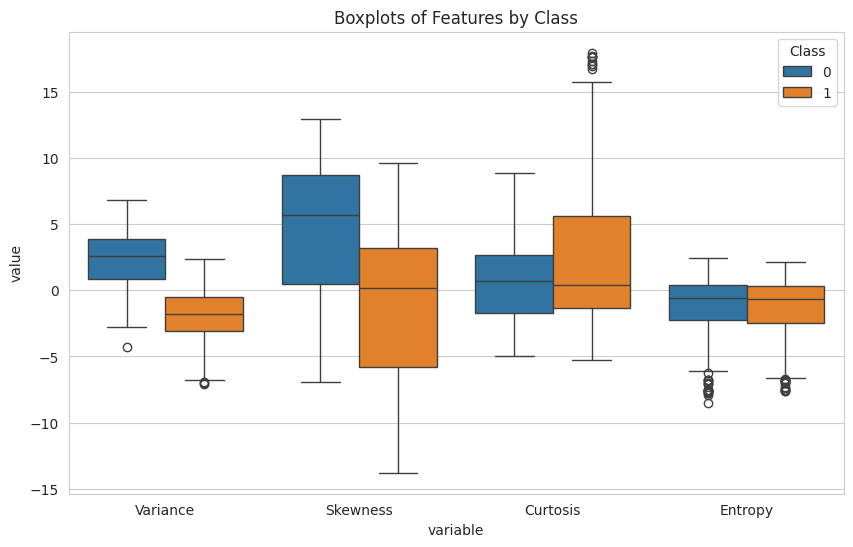

In [67]:
# Boxplots
plt.figure(figsize=(10, 6))
df_melted = df.melt(id_vars="Class", value_vars=["Variance", "Skewness", "Curtosis", "Entropy"])
sns.boxplot(data=df_melted, x="variable", y="value", hue="Class")
plt.title("Boxplots of Features by Class")
plt.show()

In [68]:
X = df[["Variance", "Skewness", "Curtosis", "Entropy"]].values
y = df["Class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1097, 4)
Testing set shape: (275, 4)


In [69]:
class Perceptron_scratch:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.errors_per_epoch = []
        self.weight_history = []
        self.bias_history = []

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for xi, yi in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                y_pred = self.step_activation(z)
                update = self.lr * (yi - y_pred)
                if update != 0.0:
                    misclassified += 1
                self.weights += update * xi
                self.bias += update

            self.errors_per_epoch.append(misclassified)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Weights: {np.round(self.weights, 4)} | Bias: {round(self.bias, 4)}")

            if misclassified == 0:
                if verbose:
                    print(f"\nConverged at epoch {epoch} (no misclassifications).")
                break

    def predict(self, X):
        return self.forward(X)


LEARNING_RATE = 0.01
N_EPOCHS = 50

model = Perceptron_scratch(n_features=X_train.shape[1], learning_rate=LEARNING_RATE, n_epochs=N_EPOCHS)
model.fit(X_train, y_train, verbose=True)

Epoch   1 | Misclassified:   59 | Weights: [-0.068  -0.0938 -0.0678 -0.011 ] | Bias: -0.03
Epoch   2 | Misclassified:   25 | Weights: [-0.0775 -0.1042 -0.0811  0.0035] | Bias: -0.04
Epoch   3 | Misclassified:   20 | Weights: [-0.0802 -0.1127 -0.0917 -0.0036] | Bias: -0.04
Epoch   4 | Misclassified:   19 | Weights: [-0.0883 -0.1196 -0.1001  0.0089] | Bias: -0.05
Epoch   5 | Misclassified:   20 | Weights: [-0.0991 -0.1295 -0.1037  0.0102] | Bias: -0.05
Epoch   6 | Misclassified:   17 | Weights: [-0.1027 -0.1277 -0.1134 -0.001 ] | Bias: -0.06
Epoch   7 | Misclassified:   24 | Weights: [-0.1081 -0.1393 -0.1108 -0.0094] | Bias: -0.06
Epoch   8 | Misclassified:   22 | Weights: [-0.117  -0.1357 -0.1319 -0.0025] | Bias: -0.06
Epoch   9 | Misclassified:   20 | Weights: [-0.1176 -0.147  -0.1364 -0.0062] | Bias: -0.06
Epoch  10 | Misclassified:   20 | Weights: [-0.1307 -0.1541 -0.125  -0.006 ] | Bias: -0.06
Epoch  11 | Misclassified:   22 | Weights: [-0.1345 -0.1641 -0.1329 -0.0018] | Bias: -0.06

Accuracy  : 0.9855
Precision : 0.9683
Recall    : 1.0000
F1-score  : 0.9839

Confusion Matrix:
[[149   4]
 [  0 122]]


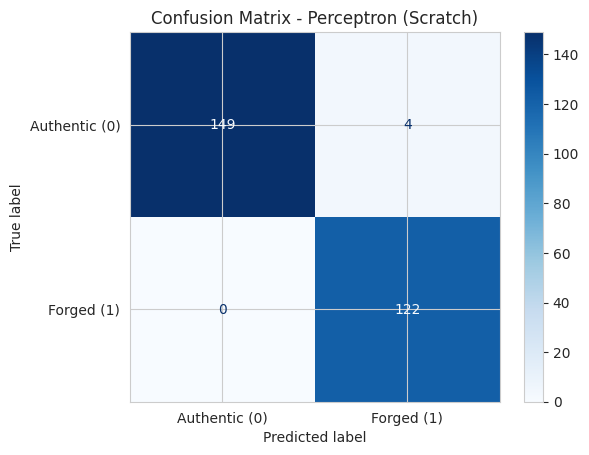

In [70]:
y_pred_test = model.predict(X_test)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic (0)", "Forged (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Perceptron (Scratch)")
plt.show()

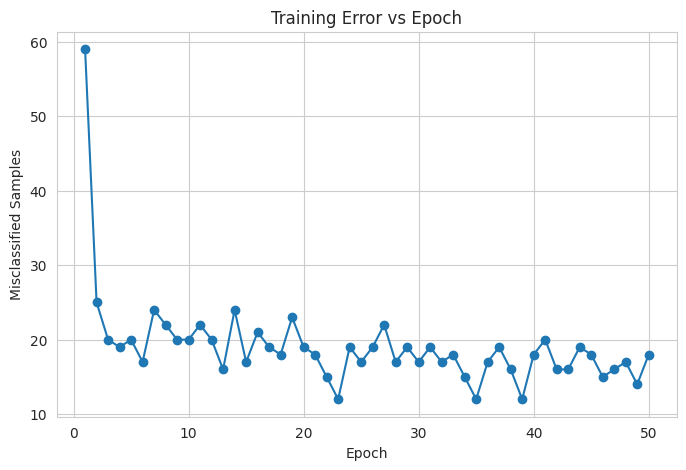

In [71]:
# Training Error vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.errors_per_epoch) + 1), model.errors_per_epoch, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.show()

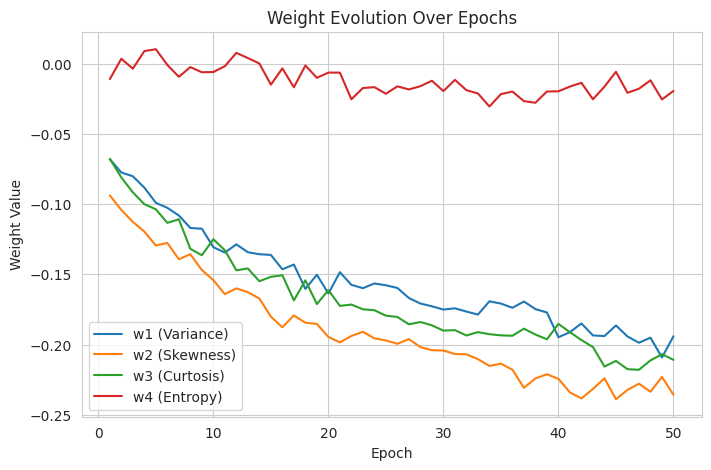

In [72]:
# Weight Evolution
weight_history = np.array(model.weight_history)
plt.figure(figsize=(8, 5))
for i in range(weight_history.shape[1]):
    plt.plot(range(1, weight_history.shape[0] + 1), weight_history[:, i], label=f"w{i+1} ({columns[i]})")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution Over Epochs")
plt.legend()
plt.show()

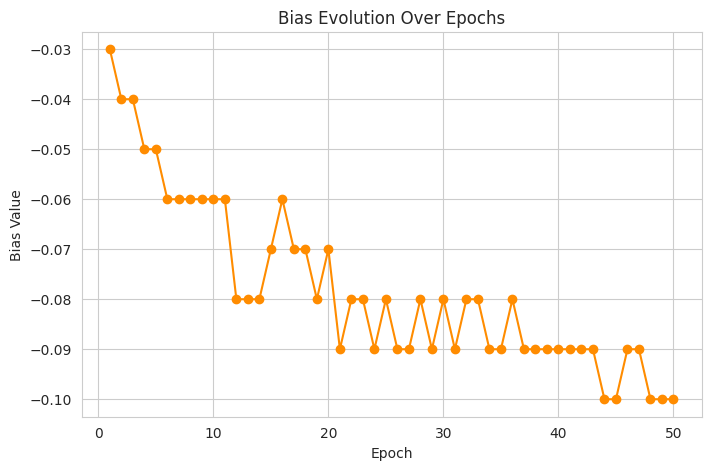

In [73]:
#  Bias Evolution
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.bias_history) + 1), model.bias_history, marker="o", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution Over Epochs")
plt.grid(True)
plt.show()

In [74]:
training_summary = pd.DataFrame({
    "Metric": ["Dataset Size", "Train Size", "Test Size", "Learning Rate", "Epochs Run",
               "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [len(df), len(X_train), len(X_test), LEARNING_RATE, len(model.errors_per_epoch),
              np.round(model.weights, 4), round(model.bias, 4),
              round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
})
display(training_summary)

,Metric,Value
0,Dataset Size,1372
1,Train Size,1097
2,Test Size,275
3,Learning Rate,0.01
4,Epochs Run,50
5,Final Weights,"[-0.1941, -0.2358, -0.2109, -0.0195]"
6,Final Bias,-0.1
7,Accuracy,0.9855
8,Precision,0.9683
9,Recall,1.0


In [75]:
epoch_table = pd.DataFrame({
    "Epoch": range(1, len(model.errors_per_epoch) + 1),
    "Errors": model.errors_per_epoch,
    "Weight 1 (Variance)": weight_history[:, 0],
    "Weight 2 (Skewness)": weight_history[:, 1],
    "Weight 3 (Curtosis)": weight_history[:, 2],
    "Weight 4 (Entropy)": weight_history[:, 3],
    "Bias": model.bias_history
})
display(epoch_table)

,Epoch,Errors,Weight 1 (Variance),Weight 2 (Skewness),Weight 3 (Curtosis),Weight 4 (Entropy),Bias
0,1,59,-0.068025,-0.093809,-0.067819,-0.011036,-0.03
1,2,25,-0.077536,-0.104214,-0.081067,0.003453,-0.04
2,3,20,-0.080213,-0.112661,-0.091664,-0.003621,-0.04
3,4,19,-0.088281,-0.119595,-0.100081,0.008909,-0.05
4,5,20,-0.099089,-0.129506,-0.103721,0.010233,-0.05
5,6,17,-0.102683,-0.127692,-0.113383,-0.000959,-0.06
6,7,24,-0.108134,-0.139275,-0.110844,-0.009393,-0.06
7,8,22,-0.117019,-0.135681,-0.131877,-0.002491,-0.06
8,9,20,-0.117554,-0.146960,-0.136437,-0.006154,-0.06
9,10,20,-0.130691,-0.154124,-0.125042,-0.006007,-0.06


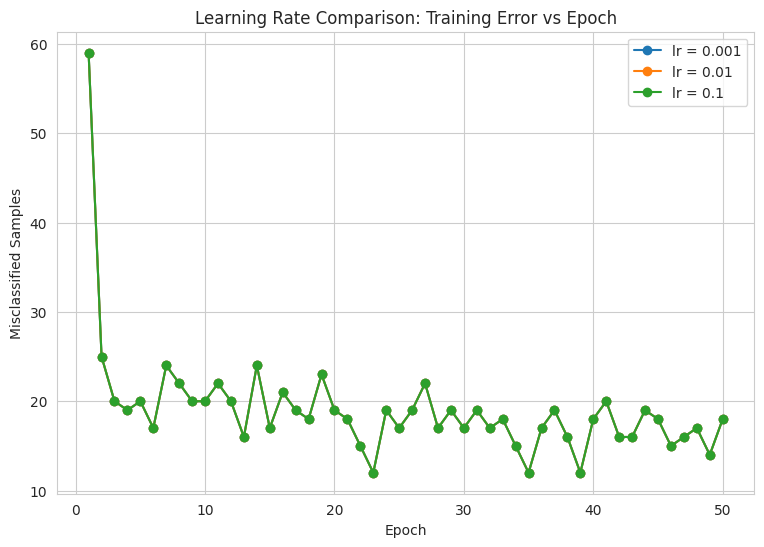

Learning Rate 0.001: Final misclassified = 18, Epochs run = 50
Learning Rate 0.01: Final misclassified = 18, Epochs run = 50
Learning Rate 0.1: Final misclassified = 18, Epochs run = 50


In [76]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

plt.figure(figsize=(9, 6))
for lr in learning_rates:
    trial_model = Perceptron_scratch(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50)
    trial_model.fit(X_train, y_train, verbose=False)
    lr_results[lr] = trial_model.errors_per_epoch
    plt.plot(range(1, len(trial_model.errors_per_epoch) + 1), trial_model.errors_per_epoch, marker="o", label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison: Training Error vs Epoch")
plt.legend()
plt.show()

for lr, errors in lr_results.items():
    print(f"Learning Rate {lr}: Final misclassified = {errors[-1]}, Epochs run = {len(errors)}")

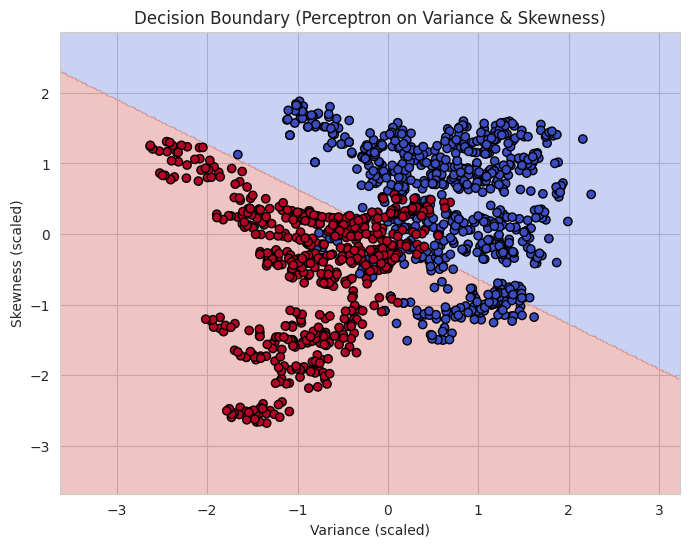

In [77]:
X_2f_train = X_train[:, :2]  # Variance and Skewness
X_2f_test = X_test[:, :2]

model_2f = Perceptron_scratch(n_features=2, learning_rate=0.01, n_epochs=50)
model_2f.fit(X_2f_train, y_train, verbose=False)

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model_2f.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlabel("Variance (scaled)")
plt.ylabel("Skewness (scaled)")
plt.title("Decision Boundary (Perceptron on Variance & Skewness)")
plt.show()


In [78]:
sk_model = Perceptron(max_iter=50, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

sk_acc = accuracy_score(y_test, y_pred_sklearn)
sk_prec = precision_score(y_test, y_pred_sklearn)
sk_rec = recall_score(y_test, y_pred_sklearn)
sk_f1 = f1_score(y_test, y_pred_sklearn)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Perceptron (Scratch)": [acc, prec, rec, f1],
    "Scikit-learn Perceptron": [sk_acc, sk_prec, sk_rec, sk_f1]
})
display(comparison)

,Metric,Perceptron (Scratch),Scikit-learn Perceptron
0,Accuracy,0.985455,0.974545
1,Precision,0.968254,0.945736
2,Recall,1.000000,1.000000
3,F1-score,0.983871,0.972112


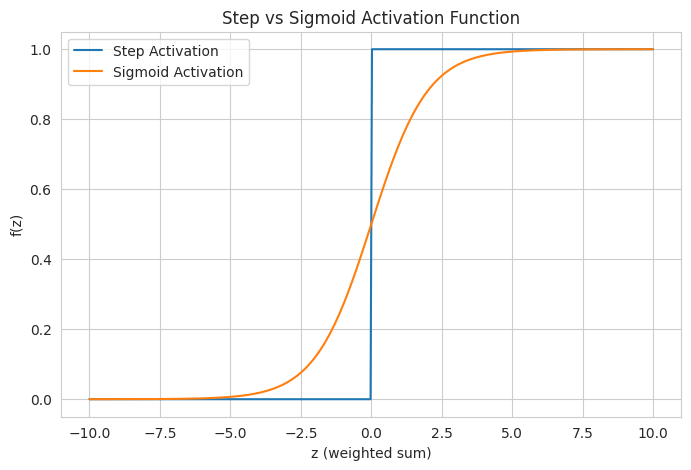

In [79]:
z = np.linspace(-10, 10, 400)
step_output = np.where(z >= 0, 1, 0)
sigmoid_output = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, step_output, label="Step Activation")
plt.plot(z, sigmoid_output, label="Sigmoid Activation")
plt.xlabel("z (weighted sum)")
plt.ylabel("f(z)")
plt.title("Step vs Sigmoid Activation Function")
plt.legend()
plt.grid(True)
plt.show()

In [80]:

class PerceptronGate:


    def __init__(self, n_features, learning_rate=0.1, max_epochs=20):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.log = []
        self.update_states = [(self.weights.copy(), self.bias, 0, None)]
        self.converged = False
        self.converged_epoch = None

    def step_activation(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.max_epochs + 1):
            epoch_updates = 0
            for i, (xi, yi) in enumerate(zip(X, y)):
                z = np.dot(xi, self.weights) + self.bias
                y_pred = self.step_activation(z)
                error = yi - y_pred

                if error != 0:
                    self.weights = self.weights + self.lr * error * xi
                    self.bias = self.bias + self.lr * error
                    epoch_updates += 1
                    self.update_states.append((self.weights.copy(), self.bias, epoch, i))

                self.log.append({
                    "epoch": epoch, "sample_idx": i, "input": xi.copy(),
                    "target": yi, "prediction": y_pred, "error": error,
                    "weights": self.weights.copy(), "bias": self.bias
                })

                if verbose:
                    tag = "UPDATED" if error != 0 else "correct"
                    print(f"Epoch {epoch:2d} | Input {xi} -> target={yi}, pred={y_pred} [{tag}] "
                          f"| Weights: {np.round(self.weights, 3)} | Bias: {round(self.bias, 3)}")

            if epoch_updates == 0:
                self.converged = True
                self.converged_epoch = epoch
                if verbose:
                    print(f"\nConverged after epoch {epoch} (no misclassifications in a full epoch).")
                return

        if verbose:
            print(f"\nDid NOT converge within {self.max_epochs} epochs "
                  f"(weights keep changing / oscillating).")

    def predict(self, X):
        X = np.atleast_2d(X)
        z = np.dot(X, self.weights) + self.bias
        return np.array([self.step_activation(zi) for zi in z])


def print_weight_updates_table(perceptron, gate_name):
    """Prints a table of weights/bias after each ACTUAL update."""
    rows = []
    for idx, (w, b, epoch, sample) in enumerate(perceptron.update_states):
        rows.append({
            "Update #": idx,
            "Epoch": epoch,
            "Sample idx": sample if sample is not None else "-",
            "Weights": np.round(w, 4),
            "Bias": round(b, 4)
        })
    table = pd.DataFrame(rows)
    print(f"\nWeights after each update — {gate_name} Gate")
    display(table)
    return table


def plot_boundary_evolution(perceptron, X, y, gate_name, max_plots=12):
    """
    Plots the decision boundary after each weight update (2-feature gates).
    If there are more updates than max_plots, only the first max_plots are shown
    (useful for XOR, which keeps updating indefinitely).
    """
    states = perceptron.update_states
    n = min(len(states), max_plots)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    x_min, x_max = -0.5, 1.5
    xs = np.linspace(x_min, x_max, 100)

    for idx in range(n):
        w, b, epoch, sample = states[idx]
        ax = axes[idx]
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=80, zorder=3)

        if abs(w[1]) > 1e-8:
            ys = -(w[0] * xs + b) / w[1]
            ax.plot(xs, ys, "k-")
        elif abs(w[0]) > 1e-8:
            ax.axvline(-b / w[0], color="k")

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(x_min, x_max)
        title = "Initial (before training)" if sample is None else f"Update {idx} (epoch {epoch}, sample {sample})"
        ax.set_title(title, fontsize=9)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{gate_name} Gate: Decision Boundary After Each Weight Update"
                 + (f"  (showing first {max_plots} of {len(states)} updates)" if len(states) > max_plots else ""))
    plt.tight_layout()
    plt.show()






Epoch  1 | Input [0 0] -> target=0, pred=1 [UPDATED] | Weights: [0. 0.] | Bias: -0.1
Epoch  1 | Input [0 1] -> target=0, pred=0 [correct] | Weights: [0. 0.] | Bias: -0.1
Epoch  1 | Input [1 0] -> target=0, pred=0 [correct] | Weights: [0. 0.] | Bias: -0.1
Epoch  1 | Input [1 1] -> target=1, pred=0 [UPDATED] | Weights: [0.1 0.1] | Bias: 0.0
Epoch  2 | Input [0 0] -> target=0, pred=1 [UPDATED] | Weights: [0.1 0.1] | Bias: -0.1
Epoch  2 | Input [0 1] -> target=0, pred=1 [UPDATED] | Weights: [0.1 0. ] | Bias: -0.2
Epoch  2 | Input [1 0] -> target=0, pred=0 [correct] | Weights: [0.1 0. ] | Bias: -0.2
Epoch  2 | Input [1 1] -> target=1, pred=0 [UPDATED] | Weights: [0.2 0.1] | Bias: -0.1
Epoch  3 | Input [0 0] -> target=0, pred=0 [correct] | Weights: [0.2 0.1] | Bias: -0.1
Epoch  3 | Input [0 1] -> target=0, pred=1 [UPDATED] | Weights: [0.2 0. ] | Bias: -0.2
Epoch  3 | Input [1 0] -> target=0, pred=1 [UPDATED] | Weights: [0.1 0. ] | Bias: -0.3
Epoch  3 | Input [1 1] -> target=1, pred=0 [UPDATE

,Update #,Epoch,Sample idx,Weights,Bias
0,0,0,-,"[0.0, 0.0]",0.0
1,1,1,0,"[0.0, 0.0]",-0.1
2,2,1,3,"[0.1, 0.1]",0.0
3,3,2,0,"[0.1, 0.1]",-0.1
4,4,2,1,"[0.1, 0.0]",-0.2
5,5,2,3,"[0.2, 0.1]",-0.1
6,6,3,1,"[0.2, 0.0]",-0.2
7,7,3,2,"[0.1, 0.0]",-0.3
8,8,3,3,"[0.2, 0.1]",-0.2


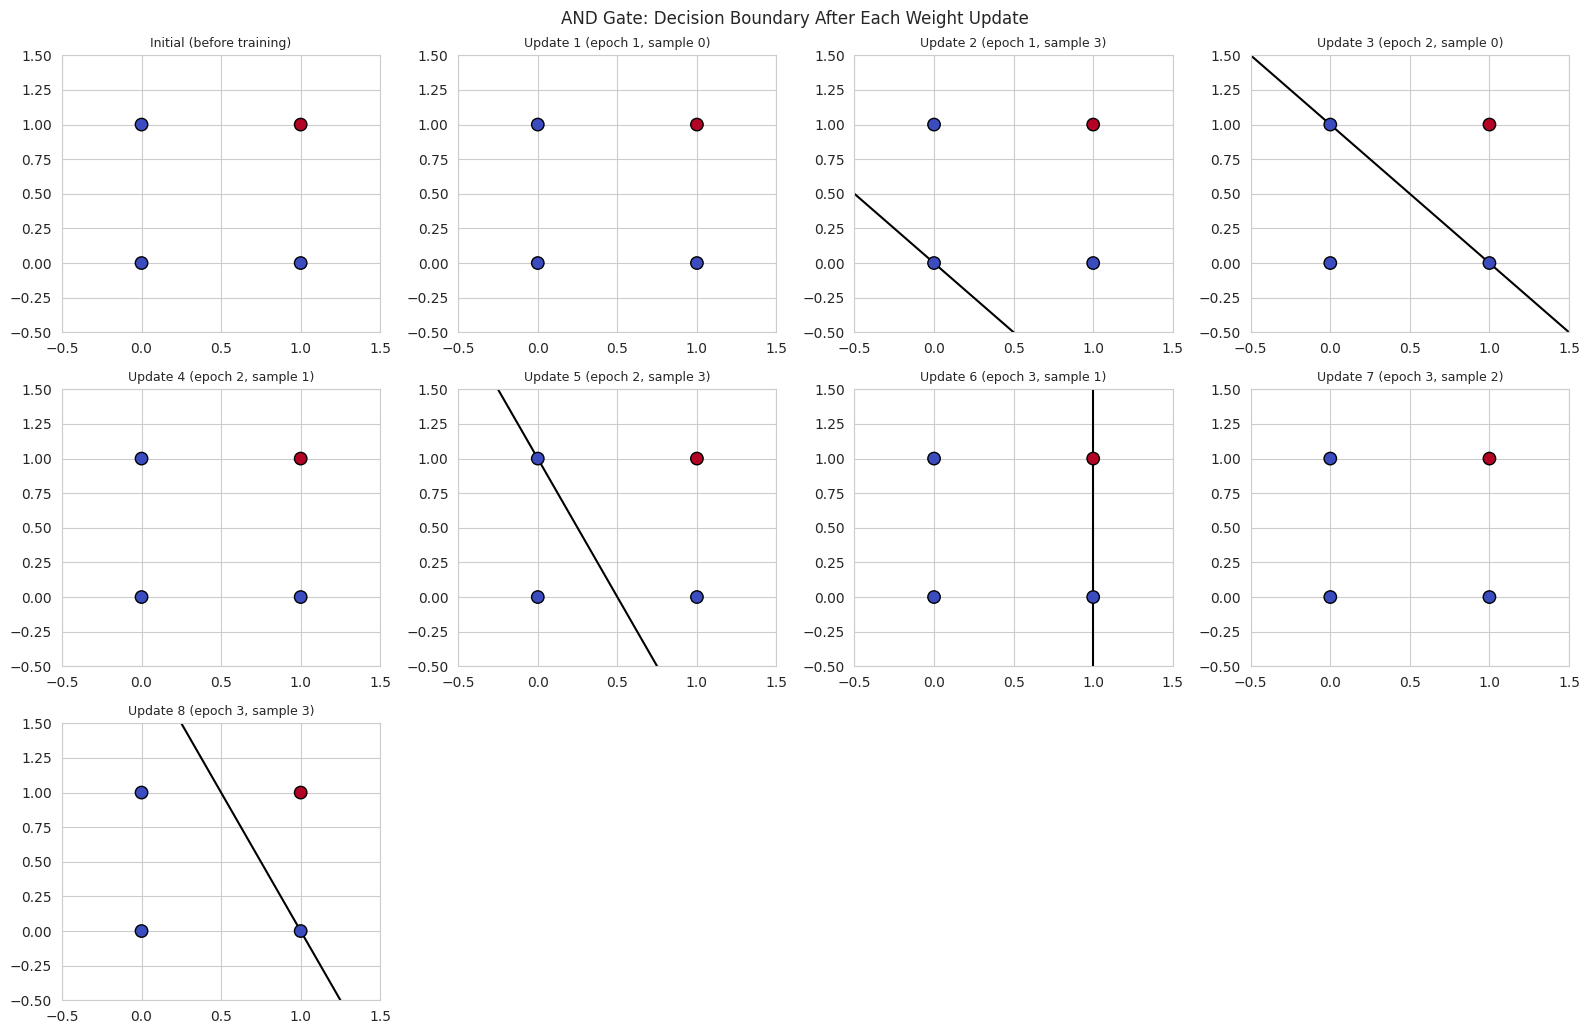

In [81]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

perc_and = PerceptronGate(n_features=2, learning_rate=0.1, max_epochs=20)
perc_and.fit(X_and, y_and, verbose=True)

print("\nFinal weights:", perc_and.weights, "| Final bias:", perc_and.bias)
print("Predictions:", perc_and.predict(X_and), "| Targets:", y_and)

print_weight_updates_table(perc_and, "AND")
plot_boundary_evolution(perc_and, X_and, y_and, "AND")




Epoch  1 | Input [0 0] -> target=0, pred=1 [UPDATED] | Weights: [0. 0.] | Bias: -0.1
Epoch  1 | Input [0 1] -> target=1, pred=0 [UPDATED] | Weights: [0.  0.1] | Bias: 0.0
Epoch  1 | Input [1 0] -> target=1, pred=1 [correct] | Weights: [0.  0.1] | Bias: 0.0
Epoch  1 | Input [1 1] -> target=1, pred=1 [correct] | Weights: [0.  0.1] | Bias: 0.0
Epoch  2 | Input [0 0] -> target=0, pred=1 [UPDATED] | Weights: [0.  0.1] | Bias: -0.1
Epoch  2 | Input [0 1] -> target=1, pred=1 [correct] | Weights: [0.  0.1] | Bias: -0.1
Epoch  2 | Input [1 0] -> target=1, pred=0 [UPDATED] | Weights: [0.1 0.1] | Bias: 0.0
Epoch  2 | Input [1 1] -> target=1, pred=1 [correct] | Weights: [0.1 0.1] | Bias: 0.0
Epoch  3 | Input [0 0] -> target=0, pred=1 [UPDATED] | Weights: [0.1 0.1] | Bias: -0.1
Epoch  3 | Input [0 1] -> target=1, pred=1 [correct] | Weights: [0.1 0.1] | Bias: -0.1
Epoch  3 | Input [1 0] -> target=1, pred=1 [correct] | Weights: [0.1 0.1] | Bias: -0.1
Epoch  3 | Input [1 1] -> target=1, pred=1 [correc

,Update #,Epoch,Sample idx,Weights,Bias
0,0,0,-,"[0.0, 0.0]",0.0
1,1,1,0,"[0.0, 0.0]",-0.1
2,2,1,1,"[0.0, 0.1]",0.0
3,3,2,0,"[0.0, 0.1]",-0.1
4,4,2,2,"[0.1, 0.1]",0.0
5,5,3,0,"[0.1, 0.1]",-0.1


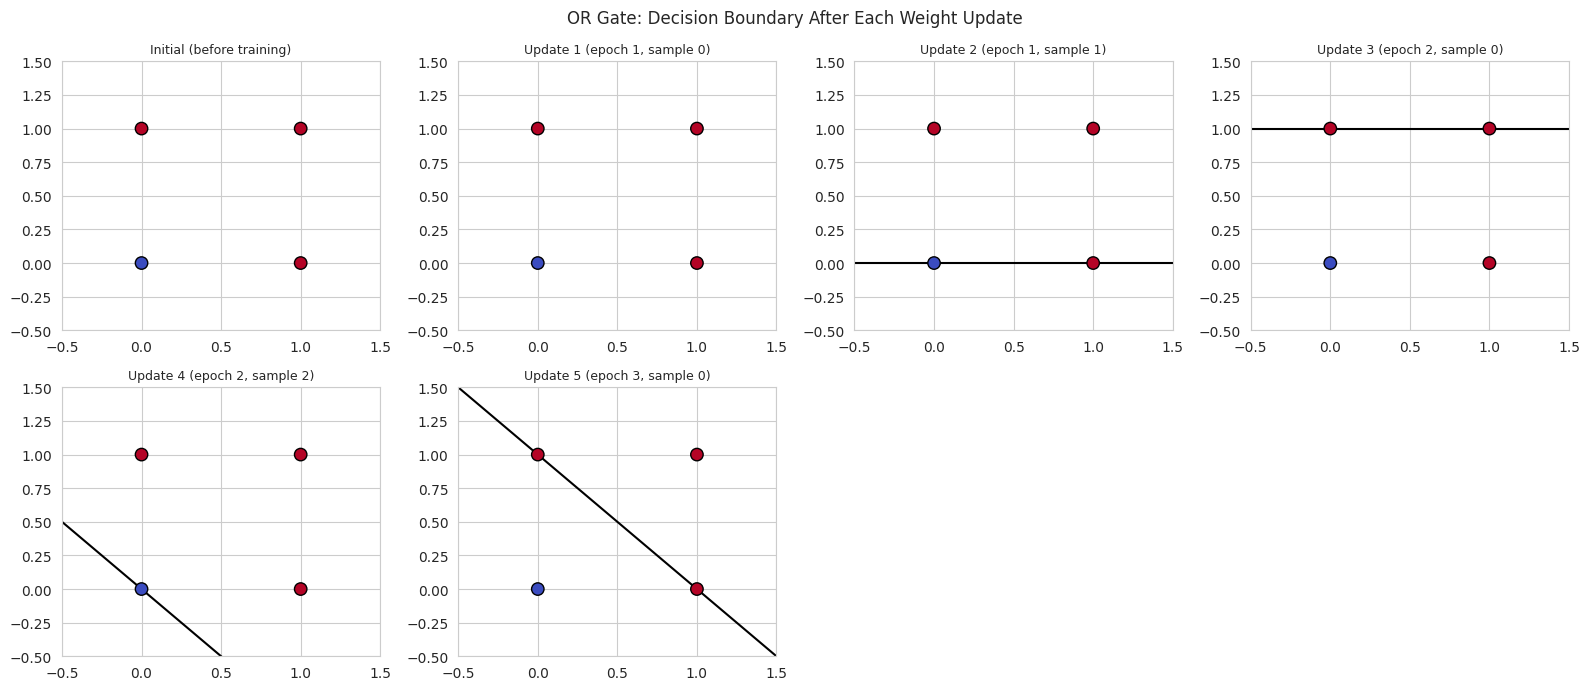

In [82]:
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

perc_or = PerceptronGate(n_features=2, learning_rate=0.1, max_epochs=20)
perc_or.fit(X_or, y_or, verbose=True)

print("\nFinal weights:", perc_or.weights, "| Final bias:", perc_or.bias)
print("Predictions:", perc_or.predict(X_or), "| Targets:", y_or)

print_weight_updates_table(perc_or, "OR")
plot_boundary_evolution(perc_or, X_or, y_or, "OR")




Epoch  1 | Input [0] -> target=1, pred=1 [correct] | Weights: [0.] | Bias: 0.0
Epoch  1 | Input [1] -> target=0, pred=1 [UPDATED] | Weights: [-0.1] | Bias: -0.1
Epoch  2 | Input [0] -> target=1, pred=0 [UPDATED] | Weights: [-0.1] | Bias: 0.0
Epoch  2 | Input [1] -> target=0, pred=0 [correct] | Weights: [-0.1] | Bias: 0.0
Epoch  3 | Input [0] -> target=1, pred=1 [correct] | Weights: [-0.1] | Bias: 0.0
Epoch  3 | Input [1] -> target=0, pred=0 [correct] | Weights: [-0.1] | Bias: 0.0

Converged after epoch 3 (no misclassifications in a full epoch).

Final weight: [-0.1] | Final bias: 0.0
Predictions: [1 0] | Targets: [1 0]

Weights after each update — NOT Gate


,Update #,Epoch,Sample idx,Weights,Bias
0,0,0,-,[0.0],0.0
1,1,1,1,[-0.1],-0.1
2,2,2,0,[-0.1],0.0


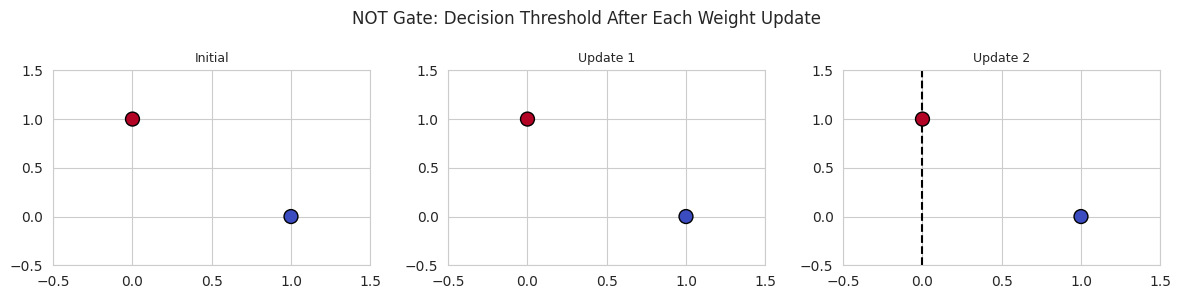

In [83]:
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

perc_not = PerceptronGate(n_features=1, learning_rate=0.1, max_epochs=20)
perc_not.fit(X_not, y_not, verbose=True)

print("\nFinal weight:", perc_not.weights, "| Final bias:", perc_not.bias)
print("Predictions:", perc_not.predict(X_not), "| Targets:", y_not)

table_not = print_weight_updates_table(perc_not, "NOT")

states = perc_not.update_states
n = len(states)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
axes = np.atleast_1d(axes)
for idx, (w, b, epoch, sample) in enumerate(states):
    ax = axes[idx]
    ax.scatter(X_not[:, 0], y_not, c=y_not, cmap="coolwarm", edgecolors="k", s=100, zorder=3)
    if abs(w[0]) > 1e-8:
        threshold = -b / w[0]
        ax.axvline(threshold, color="k", linestyle="--")
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    title = "Initial" if sample is None else f"Update {idx}"
    ax.set_title(title, fontsize=9)
fig.suptitle("NOT Gate: Decision Threshold After Each Weight Update")
plt.tight_layout()
plt.show()



Converged: False
Total individual weight updates performed: 78
Final weights (still oscillating, not meaningful as a solution): [-0.1  0. ] 0.0
Predictions after max_epochs: [1 1 0 0] | Targets: [0 1 1 0]

Weights after each update — XOR Gate


,Update #,Epoch,Sample idx,Weights,Bias
0,0,0,-,"[0.0, 0.0]",0.0
1,1,1,0,"[0.0, 0.0]",-0.1
2,2,1,1,"[0.0, 0.1]",0.0
3,3,1,3,"[-0.1, 0.0]",-0.1
4,4,2,1,"[-0.1, 0.1]",0.0
...,...,...,...,...,...
74,74,19,3,"[-0.1, 0.0]",0.0
75,75,20,0,"[-0.1, 0.0]",-0.1
76,76,20,1,"[-0.1, 0.1]",0.0
77,77,20,2,"[0.0, 0.1]",0.1


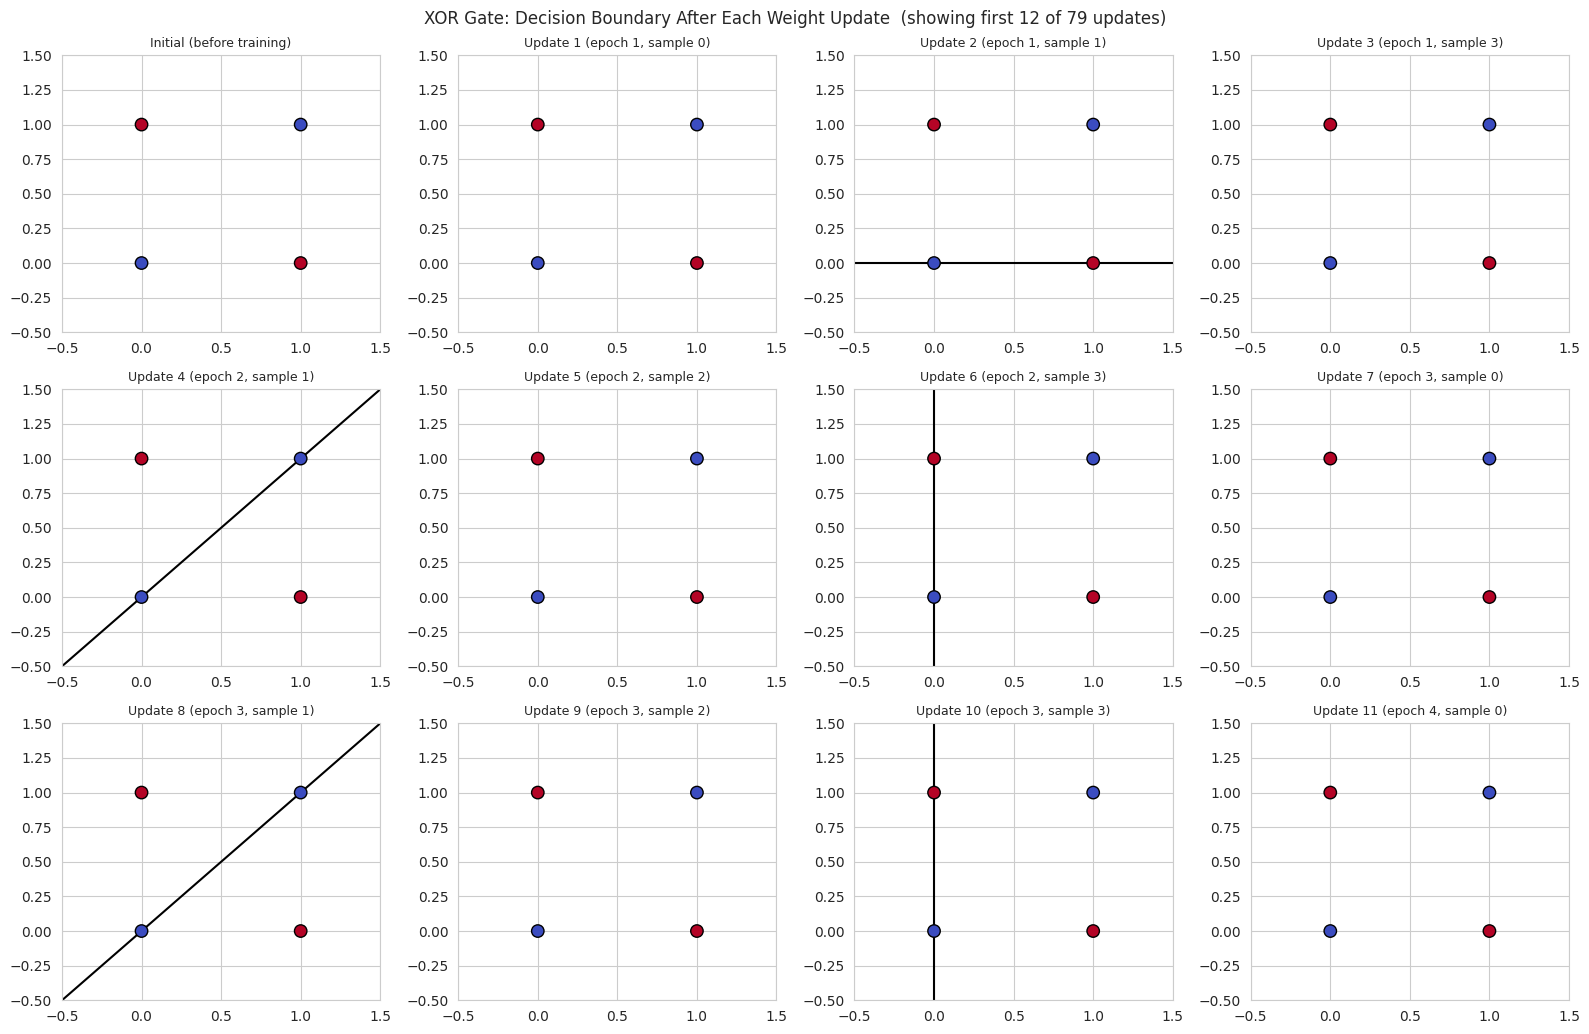

In [84]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

perc_xor = PerceptronGate(n_features=2, learning_rate=0.1, max_epochs=20)
perc_xor.fit(X_xor, y_xor, verbose=False)

print("Converged:", perc_xor.converged)
print("Total individual weight updates performed:", len(perc_xor.update_states) - 1)
print("Final weights (still oscillating, not meaningful as a solution):", perc_xor.weights, perc_xor.bias)
print("Predictions after max_epochs:", perc_xor.predict(X_xor), "| Targets:", y_xor)

print_weight_updates_table(perc_xor, "XOR")
plot_boundary_evolution(perc_xor, X_xor, y_xor, "XOR", max_plots=12)



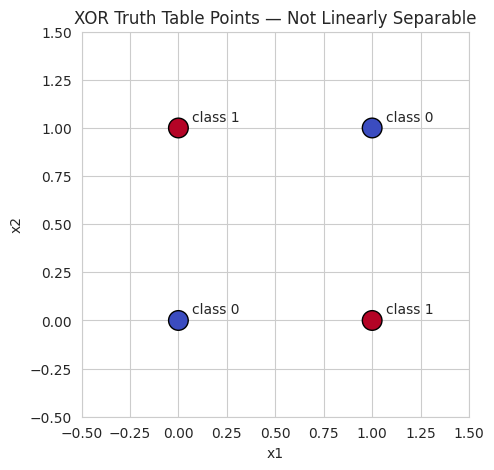

Class 0 points: (0,0) and (1,1)  -- diagonal corners
Class 1 points: (0,1) and (1,0)  -- opposite diagonal corners
Any straight line that separates one diagonal pair from the other
must simultaneously put same-class points on opposite sides -- impossible for a single line.


In [85]:
plt.figure(figsize=(5, 5))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", edgecolors="k", s=200)
for (x0, x1), label in zip(X_xor, y_xor):
    plt.annotate(f"class {label}", (x0, x1), textcoords="offset points", xytext=(10, 5))
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.title("XOR Truth Table Points — Not Linearly Separable")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

print("Class 0 points: (0,0) and (1,1)  -- diagonal corners")
print("Class 1 points: (0,1) and (1,0)  -- opposite diagonal corners")
print("Any straight line that separates one diagonal pair from the other")
print("must simultaneously put same-class points on opposite sides -- impossible for a single line.")